In [61]:
import pandas as pd

# Load both files
train = pd.read_csv('../data/train.csv')
store = pd.read_csv('../data/store.csv')

# Always look at your data before doing anything else
print(train.shape)     # (rows, columns) — how big is it?
train.head()           # shows first 5 rows

(1017209, 9)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_11976\3092249481.py:4: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('../data/train.csv')


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [62]:
train.info()        # shows column types and how many non-null values each has
train.describe()     # shows min/max/mean for numeric columns — spot weird values fast

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  str   
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(1), str(1)
memory usage: 79.5+ MB


,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [63]:
df = train.merge(store, on='Store', how='left')

In [64]:
print(df.shape)   # should have same number of rows as train, more columns

(1017209, 18)


In [66]:
df['Date'] = pd.to_datetime(df['Date'])

In [67]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week

In [68]:
df['Open'].value_counts()

Open
1    844392
0    172817
Name: count, dtype: int64

In [69]:
df = df[df['Open'] == 1].copy()

In [70]:
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(df['CompetitionDistance'].median())

In [71]:
df['Promo2SinceWeek'] = df['Promo2SinceWeek'].fillna(0)
df['Promo2SinceYear'] = df['Promo2SinceYear'].fillna(0)

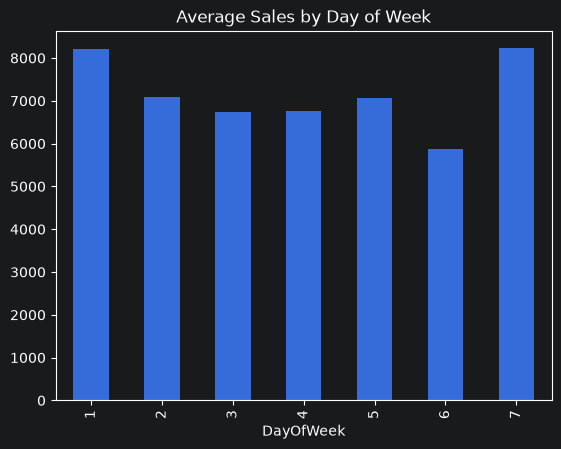

In [72]:
import matplotlib.pyplot as plt

# Average sales by day of week
df.groupby('DayOfWeek')['Sales'].mean().plot(kind='bar')
plt.title('Average Sales by Day of Week')
plt.show()

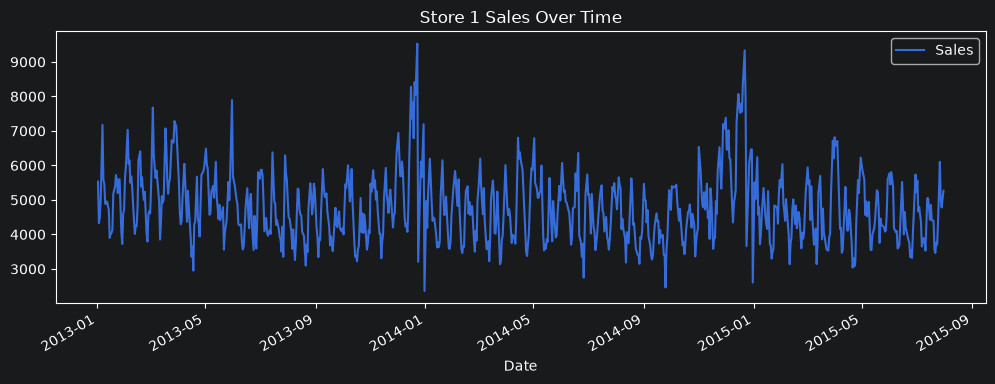

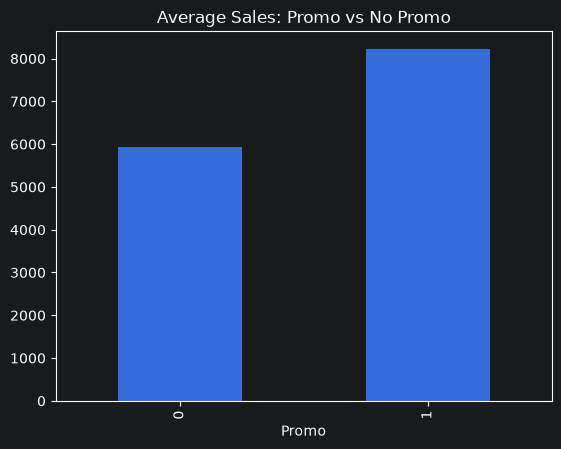

In [73]:
# Sales over time for one store
one_store = df[df['Store'] == 1]
one_store.plot(x='Date', y='Sales', figsize=(12,4))
plt.title('Store 1 Sales Over Time')
plt.show()

# Effect of promotions
df.groupby('Promo')['Sales'].mean().plot(kind='bar')
plt.title('Average Sales: Promo vs No Promo')
plt.show()

In [74]:
df = df.sort_values(['Store', 'Date'])

In [75]:
df['sales_lag_7'] = df.groupby('Store')['Sales'].shift(7)
df['sales_lag_14'] = df.groupby('Store')['Sales'].shift(14)

In [76]:
df['sales_roll_mean_7'] = df.groupby('Store')['Sales'].transform(lambda x: x.shift(1).rolling(7).mean())
df['sales_roll_std_7'] = df.groupby('Store')['Sales'].transform(lambda x: x.shift(1).rolling(7).std())

In [77]:
df = df.dropna(subset=['sales_lag_7', 'sales_lag_14', 'sales_roll_mean_7'])

In [78]:
df = pd.get_dummies(df, columns=['StoreType', 'Assortment', 'StateHoliday'], drop_first=True)

In [79]:
train_data = df[df['Date'] < '2015-06-01']
test_data = df[df['Date'] >= '2015-06-01']

In [92]:
from sklearn.metrics import mean_absolute_error

naive_pred = test_data['sales_lag_7']  # "predict same as last week"
mae_baseline = mean_absolute_error(test_data['Sales'], naive_pred)
print(f"Baseline MAE: {mae_baseline}")

Baseline MAE: 2433.9460340209175


In [88]:
import lightgbm as lgb

features = ['Store', 'DayOfWeek', 'Promo', 'Year', 'Month', 'WeekOfYear',
            'CompetitionDistance', 'sales_lag_7', 'sales_lag_14',
            'sales_roll_mean_7', 'sales_roll_std_7']

X_train, y_train = train_data[features], train_data['Sales']
X_test, y_test = test_data[features], test_data['Sales']

model = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05)
model.fit(X_train, y_train)

preds = model.predict(X_test)
mae_model = mean_absolute_error(y_test, preds)
print(f"Model MAE: {mae_model}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009939 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1609
[LightGBM] [Info] Number of data points in the train set: 770171, number of used features: 11
[LightGBM] [Info] Start training from score 6953.503084
Model MAE: 793.0700411359445


In [89]:
import pandas as pd

importance_df = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df)

                feature  importance
1             DayOfWeek        1373
5            WeekOfYear        1230
9     sales_roll_mean_7         699
10     sales_roll_std_7         554
2                 Promo         425
6   CompetitionDistance         388
3                  Year         309
8          sales_lag_14         282
7           sales_lag_7         280
0                 Store         233
4                 Month         227


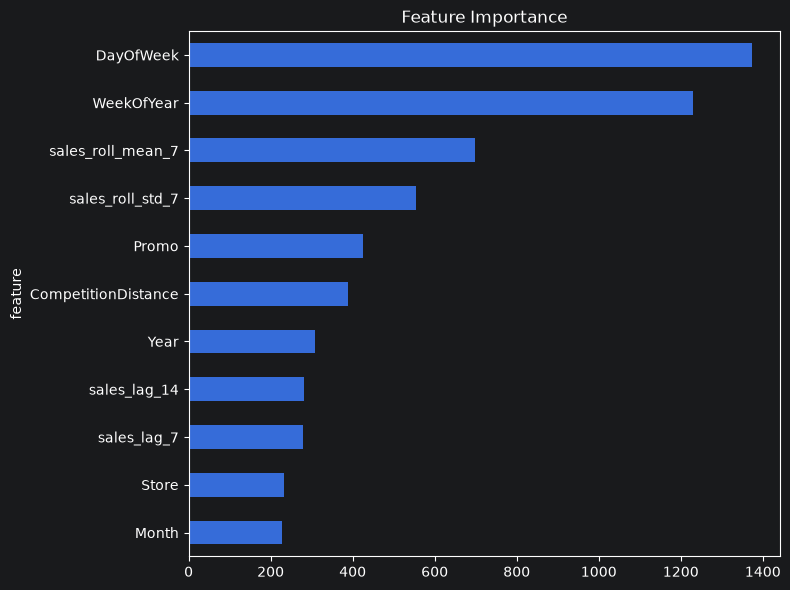

In [90]:
import matplotlib.pyplot as plt

importance_df.plot(x='feature', y='importance', kind='barh', figsize=(8,6), legend=False)
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../app/feature_importance.png')  # save it, you'll want this for the README
plt.show()

In [93]:
test_data = test_data.copy()
test_data['predicted'] = preds
test_data['residual'] = test_data['Sales'] - test_data['predicted']

# z-score, computed PER STORE (different stores have different scales)
test_data['z_score'] = test_data.groupby('Store')['residual'].transform(
    lambda x: (x - x.mean()) / x.std()
)

anomalies = test_data[test_data['z_score'].abs() > 2.5]
print(f"Found {len(anomalies)} anomalies")

Found 1134 anomalies


In [83]:
anomalies[['Store', 'Date', 'Sales', 'predicted', 'Promo', 'StateHoliday_a']].head(20)

,Store,Date,Sales,predicted,Promo,StateHoliday_a
66900,1,2015-06-01,5774,7652.559717,1,False
35680,1,2015-06-29,5197,6851.266475,1,False
34566,2,2015-06-30,9863,7429.798622,1,False
34567,3,2015-06-30,13261,10067.815555,1,False
22303,4,2015-07-11,10996,8312.934321,0,False
61330,6,2015-06-06,2800,4232.708241,0,False
35688,9,2015-06-29,13457,10359.329860,1,False
4469,10,2015-07-27,7212,9319.028812,1,False
35691,12,2015-06-29,13738,9811.635917,1,False
17852,13,2015-07-15,10334,5374.973578,1,False


In [94]:
import joblib

# Save the trained model
joblib.dump(model, '../src/model.pkl')

# Save the test data WITH predictions and anomalies already attached
test_data.to_csv('../data/test_with_predictions.csv', index=False)